<a href="https://colab.research.google.com/github/navadeepsaran/AIML_project_and_labs/blob/main/AIML_Training_Program_Module_3_project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Student Training Program on AIML**
# Project : Data Visualization, Choosing K-value and Appreciating Feature Scaling and Standardization

---

## Binary Classification Task: Diabetes Dataset

We'll be using ML techniques learnt uptil now to predict whether a Pima Indian Woman has diabetes or not, based on information about the patient such as blood pressure, body mass index (BMI), age, etc.

**Dataset Source:** [Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)


# Introduction

Scientists carried out a study to investigate the significance of health-related predictors of diabetes in **Pima Indian Women**. The study population was females (21 years and above) of Pima Indian heritage.

The purpose of the study was to find out the factors that are associated with the presence of diabetes in Pima Indians.

To find out the reason behind this, we have to first analyze the relationship between different features, such as the number of times a woman was pregnant, their BMI, prevalence of diabetes, etc.

## Exploratory Data Analysis (EDA) and Statistical Analysis

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style('whitegrid')

import warnings
warnings.filterwarnings('ignore')

## Load the Dataset

Upload the diabetes.csv file that has been provided to you.

In [2]:
# Load the dataset - upload diabetes.csv when prompted
from google.colab import files
uploaded = files.upload()  # Click "Choose Files" and upload diabetes.csv

import io
diabetes_data = pd.read_csv(io.BytesIO(uploaded['diabetes.csv']))
print("Dataset loaded successfully!")
diabetes_data.head()

Saving diabetes.csv to diabetes.csv
Dataset loaded successfully!


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


## Dataset Overview

In [3]:
# Display the first few rows
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [4]:
# Check dataset dimensions
print(f"Dataset shape: {diabetes_data.shape}")
print(f"Number of samples: {diabetes_data.shape[0]}")
print(f"Number of features: {diabetes_data.shape[1]}")

Dataset shape: (768, 9)
Number of samples: 768
Number of features: 9


In [5]:
# Dataset information
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [6]:
# Check for missing values
print("Missing values per column:")
print(diabetes_data.isnull().sum())

Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## Statistical Summary

In [7]:
# Descriptive statistics
diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.435949,12.096346,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.202592,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
# Check the target variable distribution
print("Outcome distribution:")
print(diabetes_data['Outcome'].value_counts())
print(f"\nPercentage of diabetic cases: {diabetes_data['Outcome'].mean()*100:.2f}%")

Outcome distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Percentage of diabetic cases: 34.90%


## Data Visualization

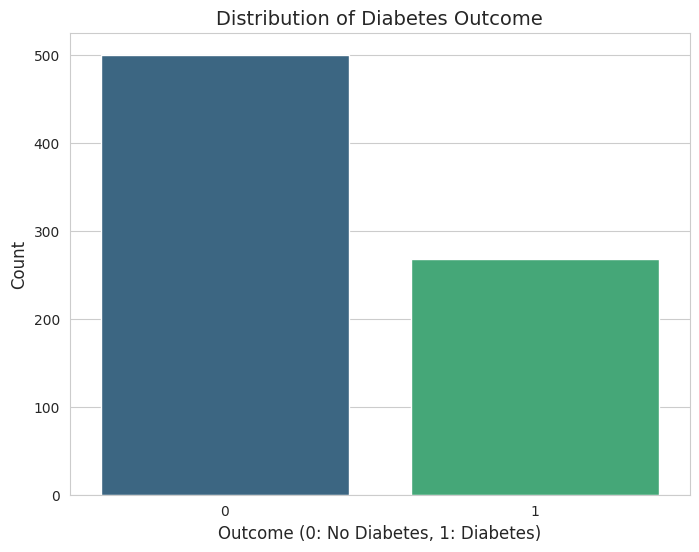

In [9]:
# Visualize the target variable distribution
plt.figure(figsize=(8,6))
sns.countplot(x='Outcome', data=diabetes_data, palette='viridis')
plt.title('Distribution of Diabetes Outcome', fontsize=14)
plt.xlabel('Outcome (0: No Diabetes, 1: Diabetes)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

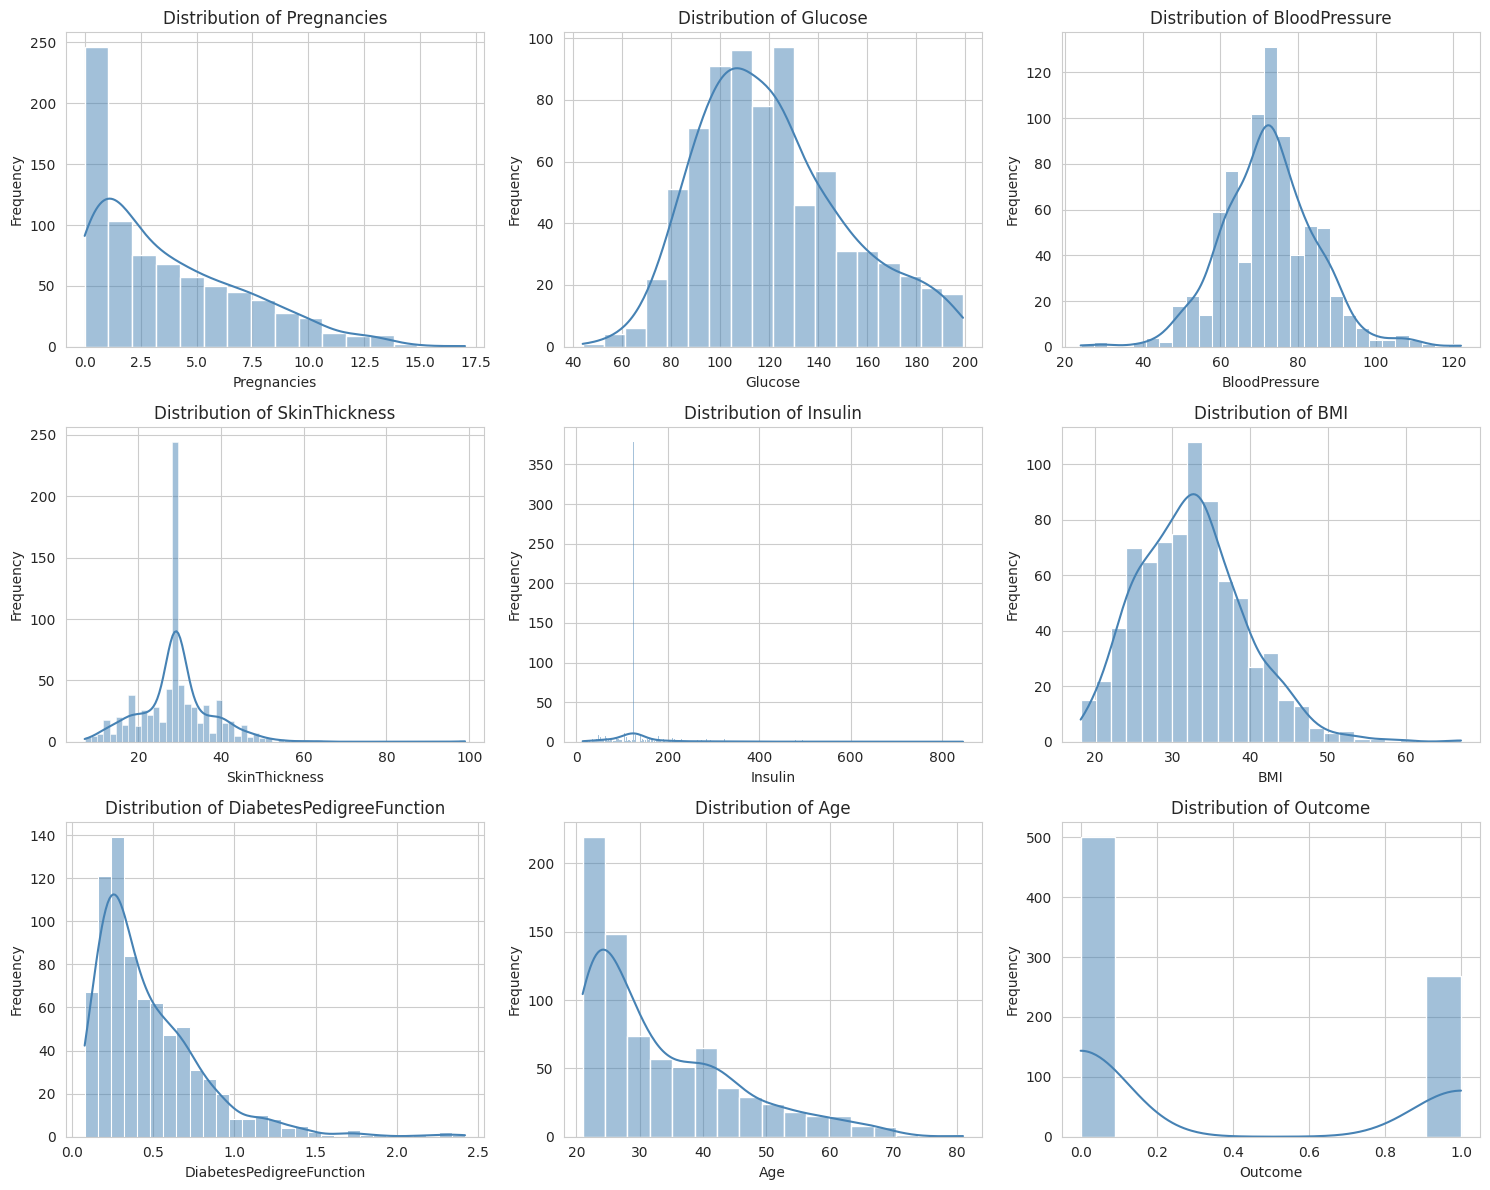

In [10]:
# Distribution of all features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(diabetes_data.columns):
    sns.histplot(diabetes_data[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)

plt.tight_layout()
plt.show()

## TASK-1: Correlation Analysis

Compute the correlation matrix and visualize it using a heatmap to understand the relationships between different features.

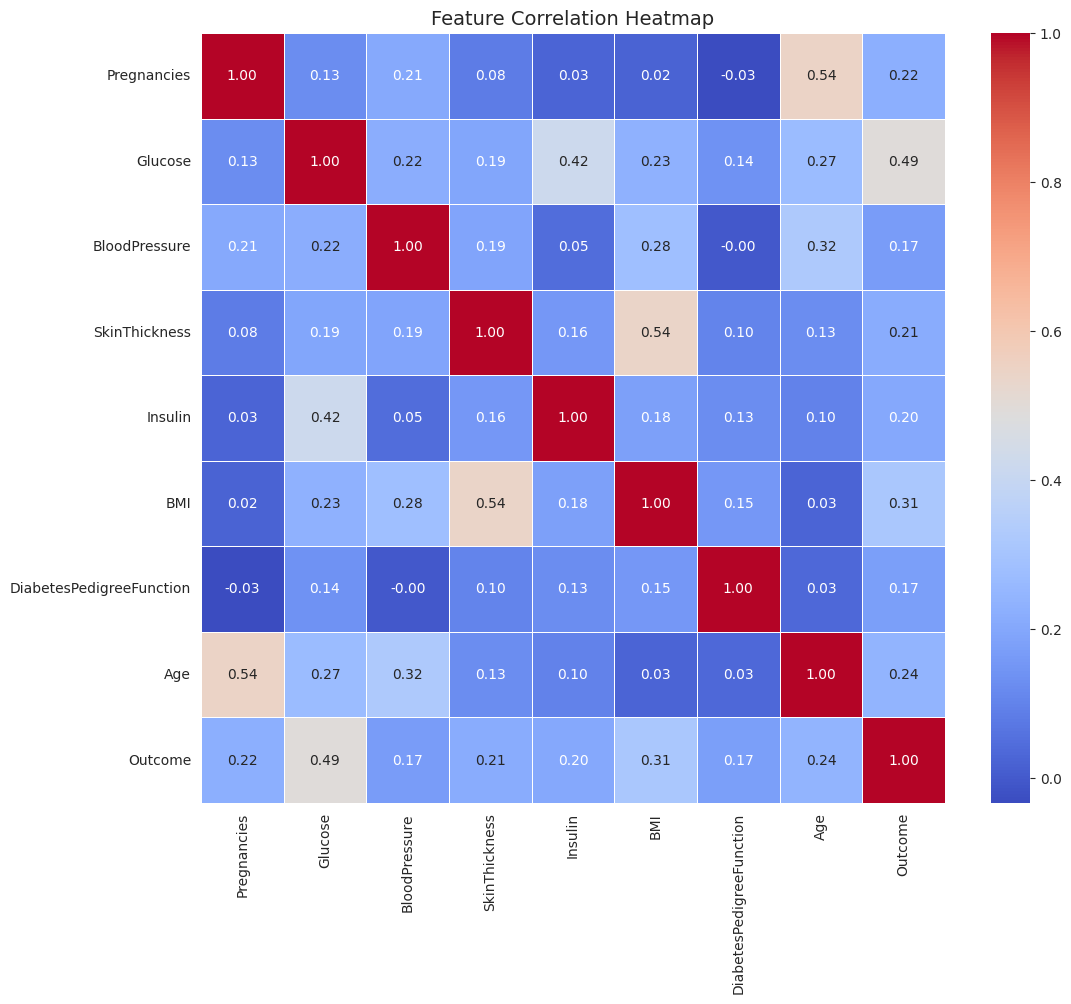

In [11]:
# Calculate correlation matrix
correlation_matrix = diabetes_data.corr()

# Visualize with heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.show()

In [12]:
# TASK-1 Extended: Print top correlations with Outcome
print("Feature Correlations with Outcome (sorted):")
print("=" * 45)
corr_with_outcome = correlation_matrix['Outcome'].drop('Outcome').sort_values(ascending=False)
for feat, val in corr_with_outcome.items():
    print(f"  {feat:<25} : {val:+.4f}")

print("\n📌 Top 4 features most correlated with Outcome:")
top4 = corr_with_outcome.abs().sort_values(ascending=False).head(4)
print(top4)

Feature Correlations with Outcome (sorted):
  Glucose                   : +0.4929
  BMI                       : +0.3120
  Age                       : +0.2384
  Pregnancies               : +0.2219
  SkinThickness             : +0.2149
  Insulin                   : +0.2038
  DiabetesPedigreeFunction  : +0.1738
  BloodPressure             : +0.1661

📌 Top 4 features most correlated with Outcome:
Glucose        0.492928
BMI            0.312038
Age            0.238356
Pregnancies    0.221898
Name: Outcome, dtype: float64


## TASK-2: Comparative Box Plots

Create box plots to compare the distribution of each feature for diabetic vs non-diabetic patients.

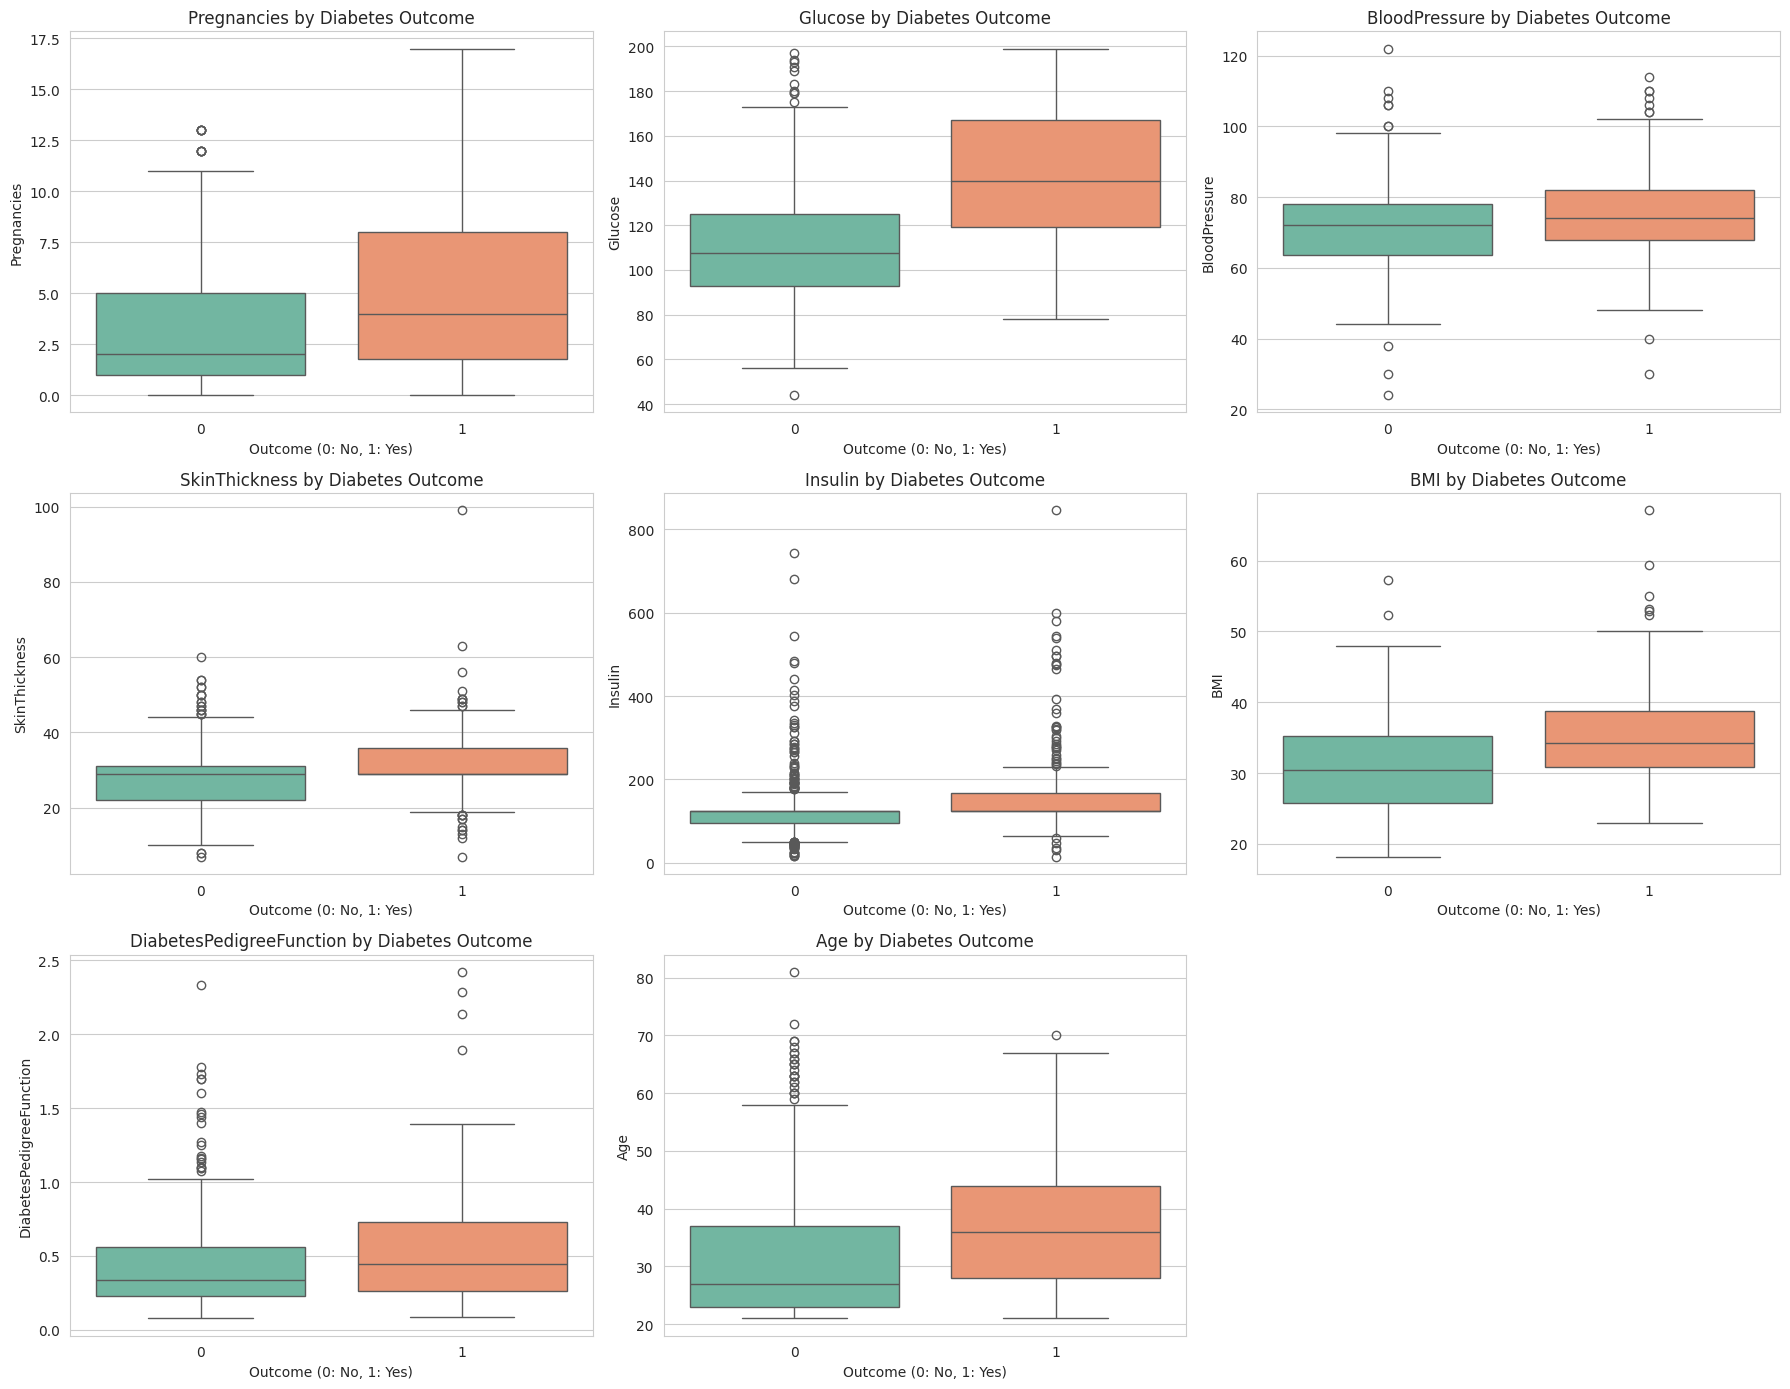

In [13]:
# Box plots for all features grouped by Outcome
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

feature_cols = diabetes_data.columns[:-1]  # All columns except Outcome

for i, col in enumerate(feature_cols):
    sns.boxplot(x='Outcome', y=col, data=diabetes_data, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} by Diabetes Outcome', fontsize=12)
    axes[i].set_xlabel('Outcome (0: No, 1: Yes)', fontsize=10)
    axes[i].set_ylabel(col, fontsize=10)

# Hide the last subplot if not needed
axes[-1].axis('off')

plt.tight_layout()
plt.show()

## TASK-3: Pairplot Analysis

Create a pairplot to visualize the pairwise relationships between features, colored by the Outcome variable.

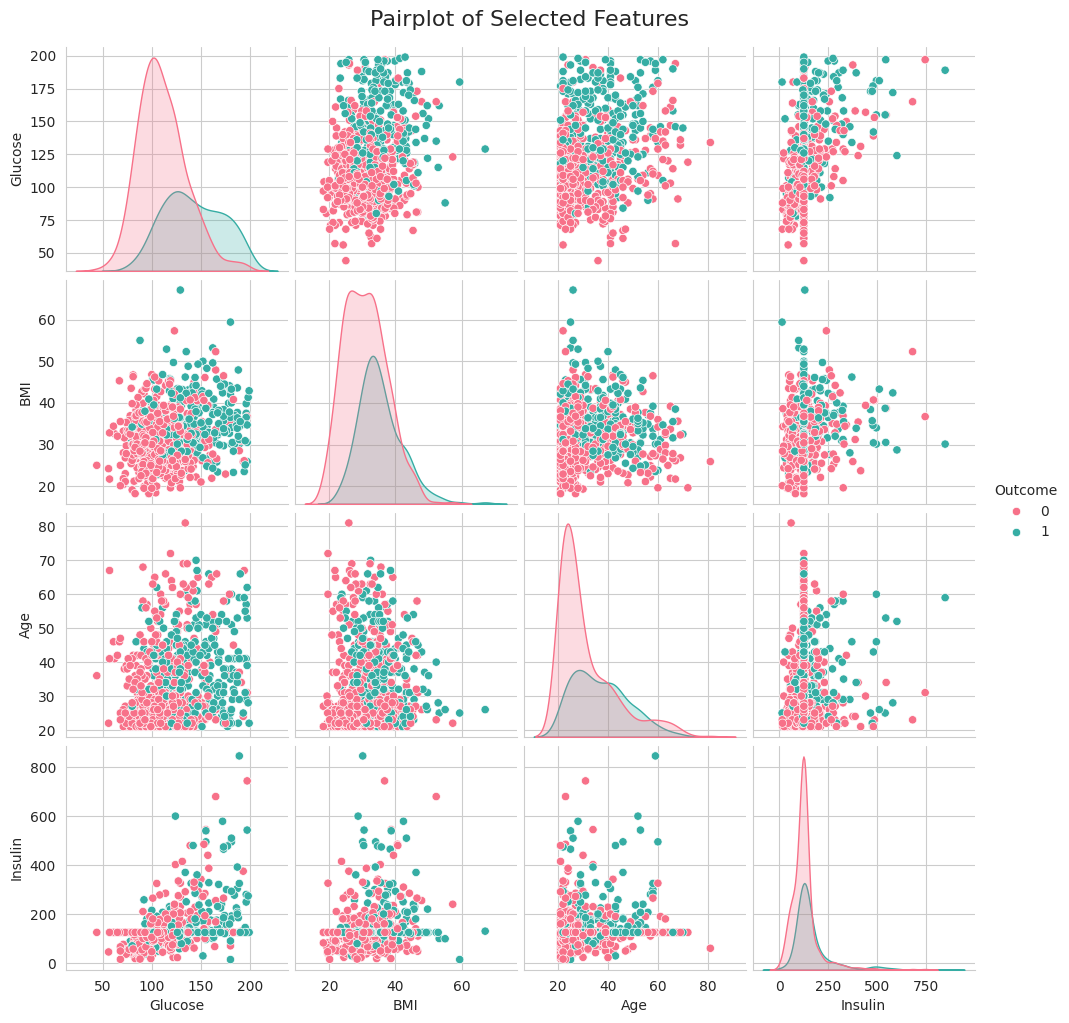

In [14]:
# Select a subset of features for clearer visualization
selected_features = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']
sns.pairplot(diabetes_data[selected_features], hue='Outcome', palette='husl', diag_kind='kde', height=2.5)
plt.suptitle('Pairplot of Selected Features', y=1.02, fontsize=16)
plt.show()

## K-Nearest Neighbors (KNN) Classification

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## TASK-4: Train-Test Split

Split the dataset into training (70%) and testing (30%) sets.

In [16]:
# Prepare features and target
X = diabetes_data.drop('Outcome', axis=1)
y = diabetes_data['Outcome']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 537
Testing set size: 231


## TASK-5: Build and Evaluate KNN Model

Train a KNN classifier with k=1 and evaluate its performance.

In [17]:
# Train KNN with k=1
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"\nAccuracy Score: {accuracy_score(y_test, y_pred)*100:.2f}%")

Confusion Matrix:
[[116  34]
 [ 42  39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.77      0.75       150
           1       0.53      0.48      0.51        81

    accuracy                           0.67       231
   macro avg       0.63      0.63      0.63       231
weighted avg       0.66      0.67      0.67       231


Accuracy Score: 67.10%


## TASK-6: Finding the Optimal K Value

Test different values of K (from 1 to 40) and plot the error rate to find the optimal K value.

In [18]:
# Store the original unscaled data for later comparison
unchanged_data = X.copy()

# Function to evaluate KNN performance across different K values
def plot_KNN_error_rate(xdata, ydata):
    error_rate = []
    test_scores = []
    train_scores = []

    X_train, X_test, y_train, y_test = train_test_split(xdata, ydata, test_size=0.3, random_state=101)

    for i in range(1, 40):
        knn = KNeighborsClassifier(n_neighbors=i)
        knn.fit(X_train, y_train)
        pred_i = knn.predict(X_test)

        error_rate.append(np.mean(pred_i != y_test))
        train_scores.append(knn.score(X_train, y_train))
        test_scores.append(knn.score(X_test, y_test))

    # Plot error rate
    plt.figure(figsize=(12, 8))
    plt.plot(range(1, 40), error_rate, color='blue', linestyle='dashed', marker='o',
             markerfacecolor='red', markersize=8)
    plt.title('Error Rate vs. K Value', fontsize=14)
    plt.xlabel('K', fontsize=12)
    plt.ylabel('Error Rate', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

    # Find best K values
    max_train_score = max(train_scores)
    train_scores_ind = [i for i, v in enumerate(train_scores) if v == max_train_score]
    print(f'Max train score: {max_train_score*100:.2f}% at K = {[x+1 for x in train_scores_ind]}')

    max_test_score = max(test_scores)
    test_scores_ind = [i for i, v in enumerate(test_scores) if v == max_test_score]
    print(f'Max test score: {max_test_score*100:.2f}% at K = {[x+1 for x in test_scores_ind]}')

    return test_scores

Performance on Unscaled Data:


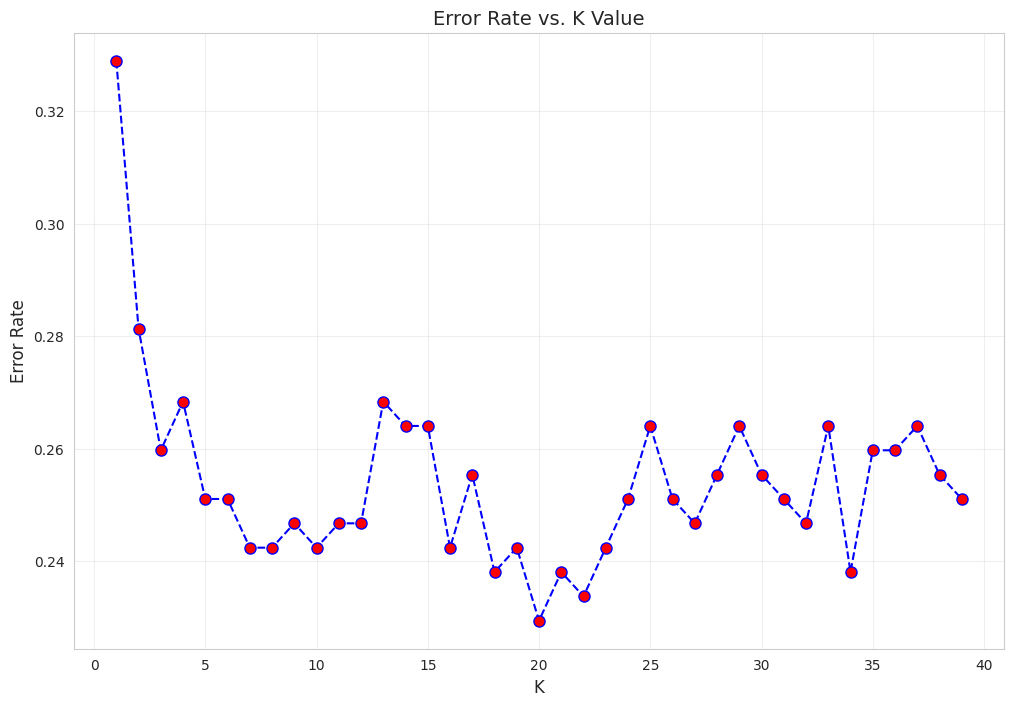

Max train score: 100.00% at K = [1]
Max test score: 77.06% at K = [20]


In [19]:
# Evaluate on unscaled data
print("Performance on Unscaled Data:")
unchanged_test_scores = plot_KNN_error_rate(unchanged_data, diabetes_data['Outcome'])

## Standardize the Variables

Standardization (also called z-score normalization) is the process of putting different variables on the same scale. Standardization transforms your data such that the resulting distribution has a mean of 0 and a standard deviation of 1.

$$ Z = {X - \mu \over \sigma}$$

Where:
- Z is the standardized value
- X is the original value
- μ is the mean of the feature
- σ is the standard deviation of the feature

In [20]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on training data features
scaler.fit(diabetes_data.drop('Outcome', axis=1))

# Transform the features
scaled_data = scaler.transform(diabetes_data.drop('Outcome', axis=1))

In [21]:
# Create a dataframe with scaled features
df_feat = pd.DataFrame(scaled_data, columns=diabetes_data.columns[:-1])
df_feat.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.865108,-0.033518,0.670643,-0.181541,0.166619,0.468492,1.425995
1,-0.844885,-1.206162,-0.529859,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672
2,1.233880,2.015813,-0.695306,-0.012301,-0.181541,-1.332500,0.604397,-0.105584
3,-0.844885,-1.074652,-0.529859,-0.695245,-0.540642,-0.633881,-0.920763,-1.041549
4,-1.141852,0.503458,-2.680669,0.670643,0.316566,1.549303,5.484909,-0.020496


In [22]:
# Verify standardization: mean should be ~0, std should be ~1
print("Mean of scaled features:")
print(df_feat.mean())
print("\nStandard deviation of scaled features:")
print(df_feat.std())

Mean of scaled features:
Pregnancies                -6.476301e-17
Glucose                    -3.561966e-16
BloodPressure              -4.325244e-16
SkinThickness              -1.526557e-16
Insulin                     1.503427e-17
BMI                         2.613650e-16
DiabetesPedigreeFunction    2.174187e-16
Age                         1.931325e-16
dtype: float64

Standard deviation of scaled features:
Pregnancies                 1.000652
Glucose                     1.000652
BloodPressure               1.000652
SkinThickness               1.000652
Insulin                     1.000652
BMI                         1.000652
DiabetesPedigreeFunction    1.000652
Age                         1.000652
dtype: float64


Performance on Standardized Data:


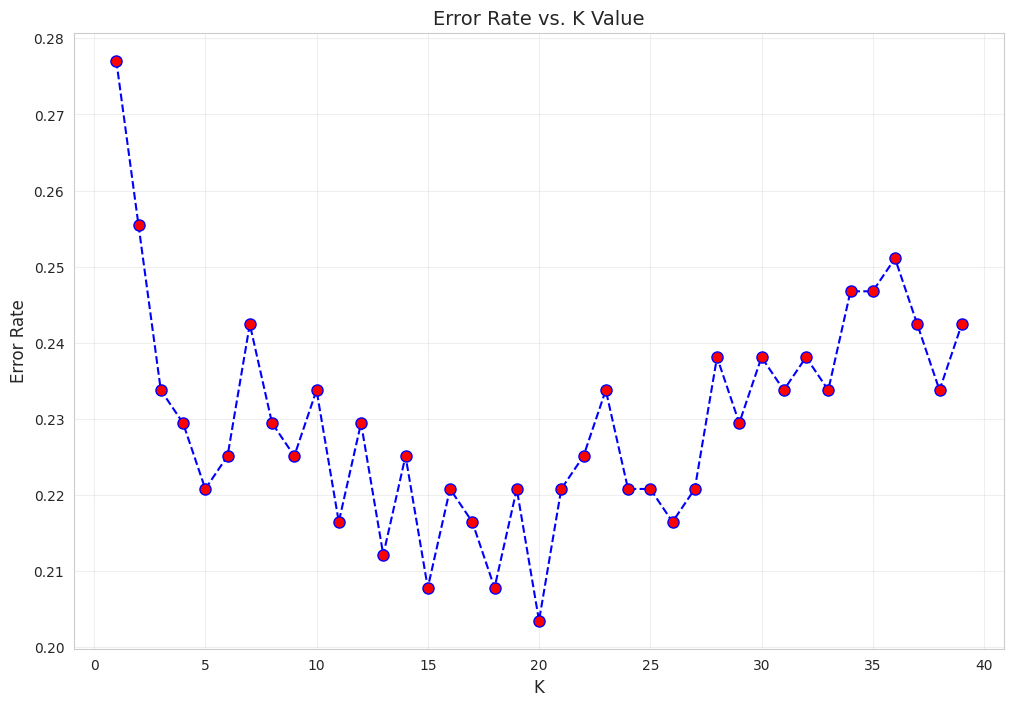

Max train score: 100.00% at K = [1]
Max test score: 79.65% at K = [20]


In [23]:
# Evaluate on scaled data
print("Performance on Standardized Data:")
scaled_test_scores = plot_KNN_error_rate(scaled_data, diabetes_data['Outcome'])

## Comparing Accuracy Before and After Standardization

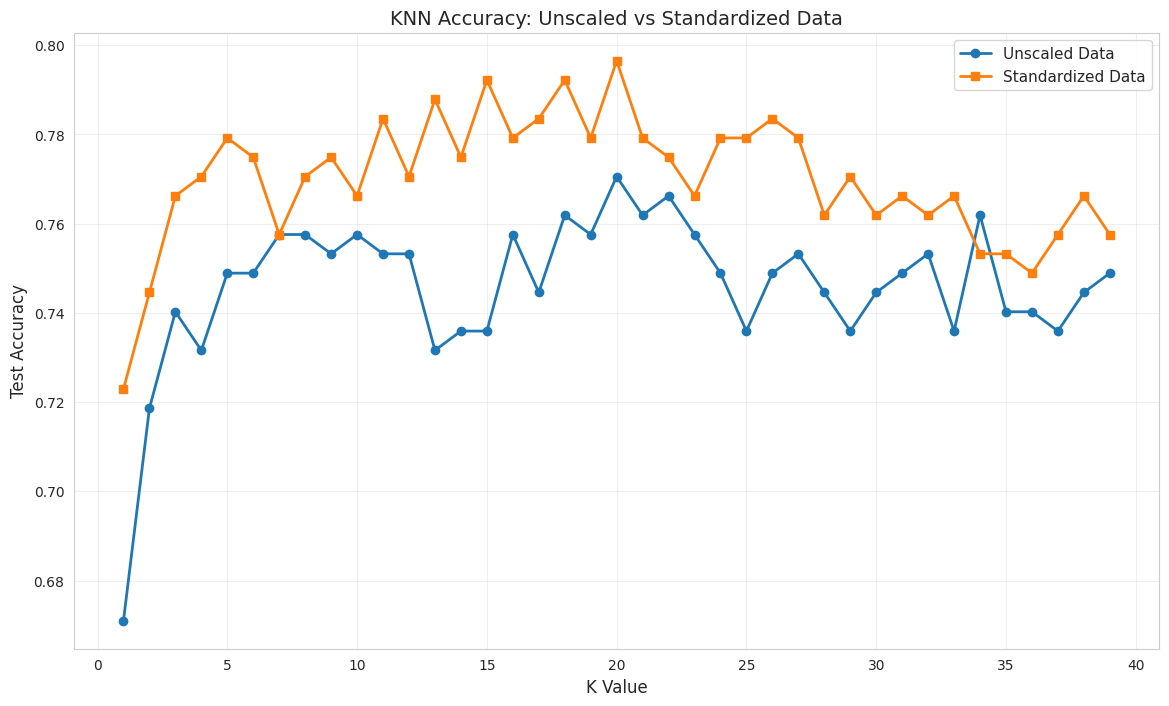

In [24]:
# Compare performance
plt.figure(figsize=(14, 8))
plt.plot(range(1, 40), unchanged_test_scores, marker='o', label='Unscaled Data', linewidth=2)
plt.plot(range(1, 40), scaled_test_scores, marker='s', label='Standardized Data', linewidth=2)
plt.title('KNN Accuracy: Unscaled vs Standardized Data', fontsize=14)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

# Conclusion

From the data analysis we carried out, it seems that there is some form of an association between BMI, number of pregnancies, glucose levels, and the test results for diabetes.

As for the classification tasks, the standardized data yields much better results than the unscaled data over most of the K-values considered, thus indicating the importance of standardizing data in Machine Learning problems. This improvement occurs because:

1. KNN is distance-based and features with larger scales dominate the distance calculation
2. Standardization puts all features on equal footing
3. This leads to more balanced and accurate predictions

---
# DIY Challenges

Test your understanding by completing these three challenges. Solutions are not provided - work through them independently!

## Challenge 1: MinMax Scaling Comparison

**Objective:** Implement MinMax scaling and compare its performance with StandardScaler.

**Tasks:**
1. Import `MinMaxScaler` from sklearn.preprocessing
2. Apply MinMax scaling to the dataset (scales features to range [0, 1])
3. Use the `plot_KNN_error_rate()` function on the MinMax-scaled data
4. Create a comparison plot showing all three approaches: unscaled, standardized, and MinMax-scaled
5. Analyze which scaling method performs best and why

**Hint:** MinMaxScaler formula is: $X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}$

MinMax Scaled Data — Min values (should be ~0):
Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
dtype: float64

MinMax Scaled Data — Max values (should be ~1):
Pregnancies                 1.0
Glucose                     1.0
BloodPressure               1.0
SkinThickness               1.0
Insulin                     1.0
BMI                         1.0
DiabetesPedigreeFunction    1.0
Age                         1.0
dtype: float64

Performance on MinMax-Scaled Data:


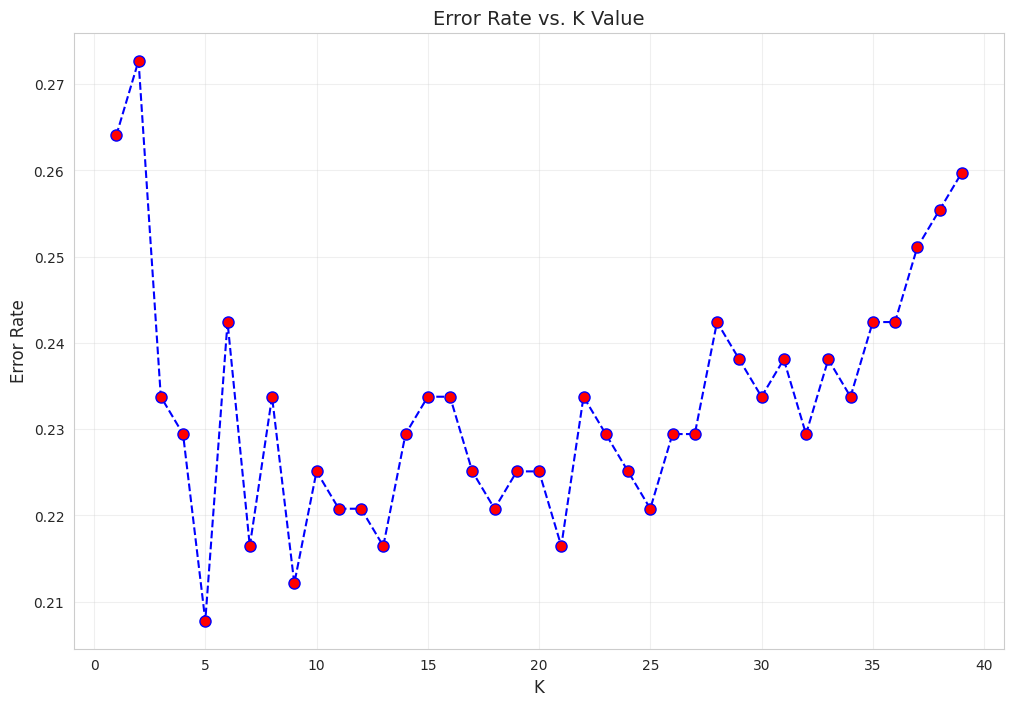

Max train score: 100.00% at K = [1]
Max test score: 79.22% at K = [5]


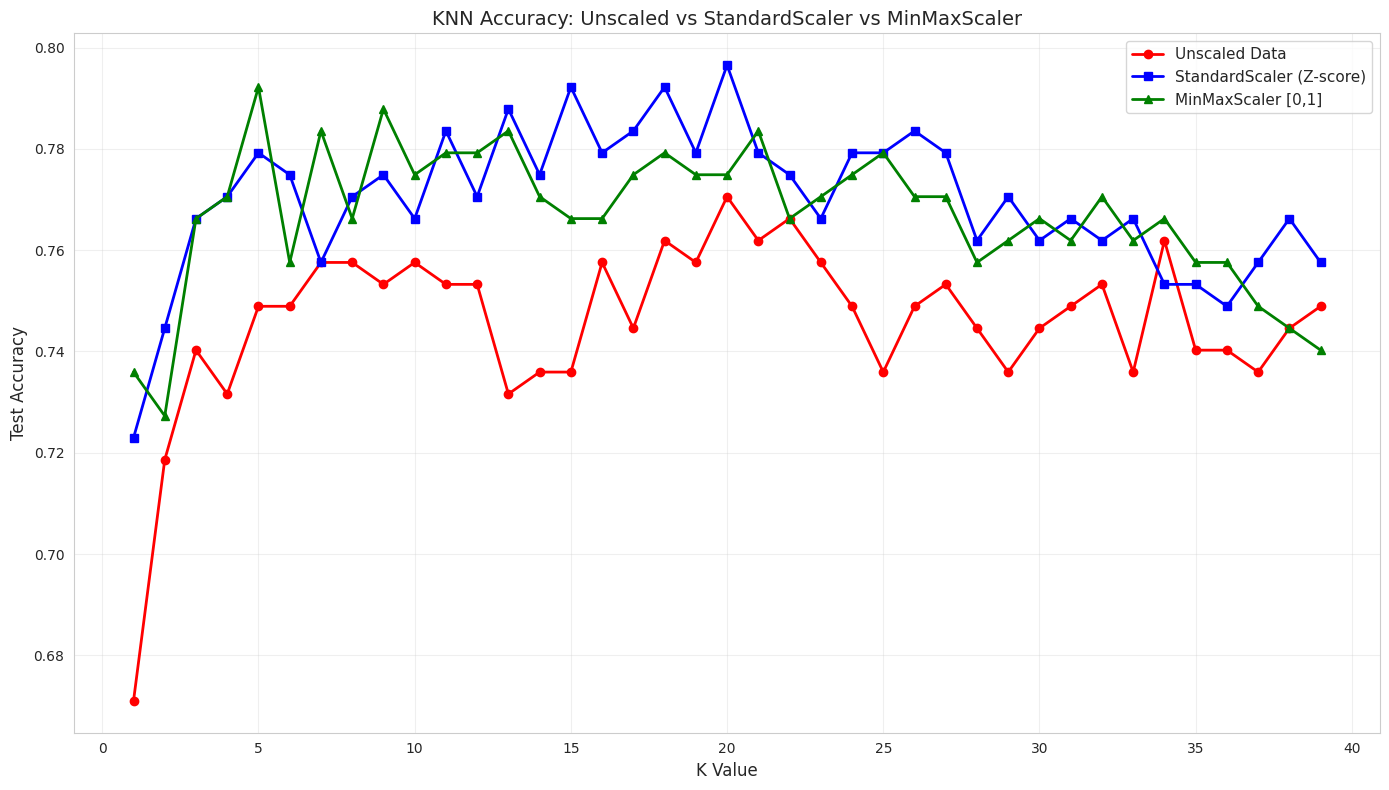


SUMMARY: Best accuracy per approach
  Unscaled:       77.06%  at K=20
  StandardScaler: 79.65%  at K=20
  MinMaxScaler:   79.22%  at K=5

ANALYSIS:
- Unscaled:        Features like Insulin (0-846) dominate distance calculations
                   over features like Pregnancies (0-17). This biases KNN heavily.
- StandardScaler:  Centers each feature at mean=0, std=1. Removes scale bias.
                   Works best when features follow a roughly Gaussian distribution.
- MinMaxScaler:    Squishes all features to [0,1]. Also removes scale bias but
                   is sensitive to outliers (extreme values compress the rest).
- Both scaling methods significantly outperform unscaled data for KNN because
  KNN is purely distance-based — scale fairness is critical.



In [25]:
# Your code here for Challenge 1
# ============================================================
# CHALLENGE 1: MinMax Scaling Comparison
# ============================================================

from sklearn.preprocessing import MinMaxScaler

# Step 1: Apply MinMax Scaling
# MinMax formula: X_scaled = (X - X_min) / (X_max - X_min)
# This squishes all values into the range [0, 1]
minmax_scaler = MinMaxScaler()
minmax_scaled_data = minmax_scaler.fit_transform(diabetes_data.drop('Outcome', axis=1))

# Step 2: Verify the scaling — min should be 0, max should be 1
df_minmax = pd.DataFrame(minmax_scaled_data, columns=diabetes_data.columns[:-1])
print("MinMax Scaled Data — Min values (should be ~0):")
print(df_minmax.min().round(4))
print("\nMinMax Scaled Data — Max values (should be ~1):")
print(df_minmax.max().round(4))

# Step 3: Evaluate KNN on MinMax-scaled data
print("\nPerformance on MinMax-Scaled Data:")
minmax_test_scores = plot_KNN_error_rate(minmax_scaled_data, diabetes_data['Outcome'])

# Step 4: Comparison plot — all three approaches
plt.figure(figsize=(14, 8))
plt.plot(range(1, 40), unchanged_test_scores, marker='o',
         label='Unscaled Data',        linewidth=2, color='red')
plt.plot(range(1, 40), scaled_test_scores,   marker='s',
         label='StandardScaler (Z-score)', linewidth=2, color='blue')
plt.plot(range(1, 40), minmax_test_scores,   marker='^',
         label='MinMaxScaler [0,1]',    linewidth=2, color='green')

plt.title('KNN Accuracy: Unscaled vs StandardScaler vs MinMaxScaler', fontsize=14)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Step 5: Summary table
print("\n" + "="*55)
print("SUMMARY: Best accuracy per approach")
print("="*55)
print(f"  Unscaled:       {max(unchanged_test_scores)*100:.2f}%  at K={unchanged_test_scores.index(max(unchanged_test_scores))+1}")
print(f"  StandardScaler: {max(scaled_test_scores)*100:.2f}%  at K={scaled_test_scores.index(max(scaled_test_scores))+1}")
print(f"  MinMaxScaler:   {max(minmax_test_scores)*100:.2f}%  at K={minmax_test_scores.index(max(minmax_test_scores))+1}")

print("""
ANALYSIS:
- Unscaled:        Features like Insulin (0-846) dominate distance calculations
                   over features like Pregnancies (0-17). This biases KNN heavily.
- StandardScaler:  Centers each feature at mean=0, std=1. Removes scale bias.
                   Works best when features follow a roughly Gaussian distribution.
- MinMaxScaler:    Squishes all features to [0,1]. Also removes scale bias but
                   is sensitive to outliers (extreme values compress the rest).
- Both scaling methods significantly outperform unscaled data for KNN because
  KNN is purely distance-based — scale fairness is critical.
""")

## Challenge 2: K-Fold Cross-Validation Analysis

**Objective:** Implement K-Fold cross-validation to get more robust performance estimates.

**Tasks:**
1. Import `cross_val_score` from sklearn.model_selection
2. Implement 5-fold cross-validation for KNN with K values from 1 to 40
3. Compare cross-validation scores for:
   - Unscaled data
   - Standardized data
   - MinMax-scaled data (from Challenge 1)
4. Plot the mean cross-validation accuracy with standard deviation error bars
5. Determine the optimal K value for each scaling approach

**Bonus:** Calculate and display the standard deviation of cross-validation scores to understand model stability.

Running 5-Fold Cross-Validation for K = 1 to 39...
(This may take a moment)

  Unscaled             → Best CV Accuracy: 75.26% at K=31
  StandardScaler       → Best CV Accuracy: 77.22% at K=25
  MinMaxScaler         → Best CV Accuracy: 77.35% at K=21


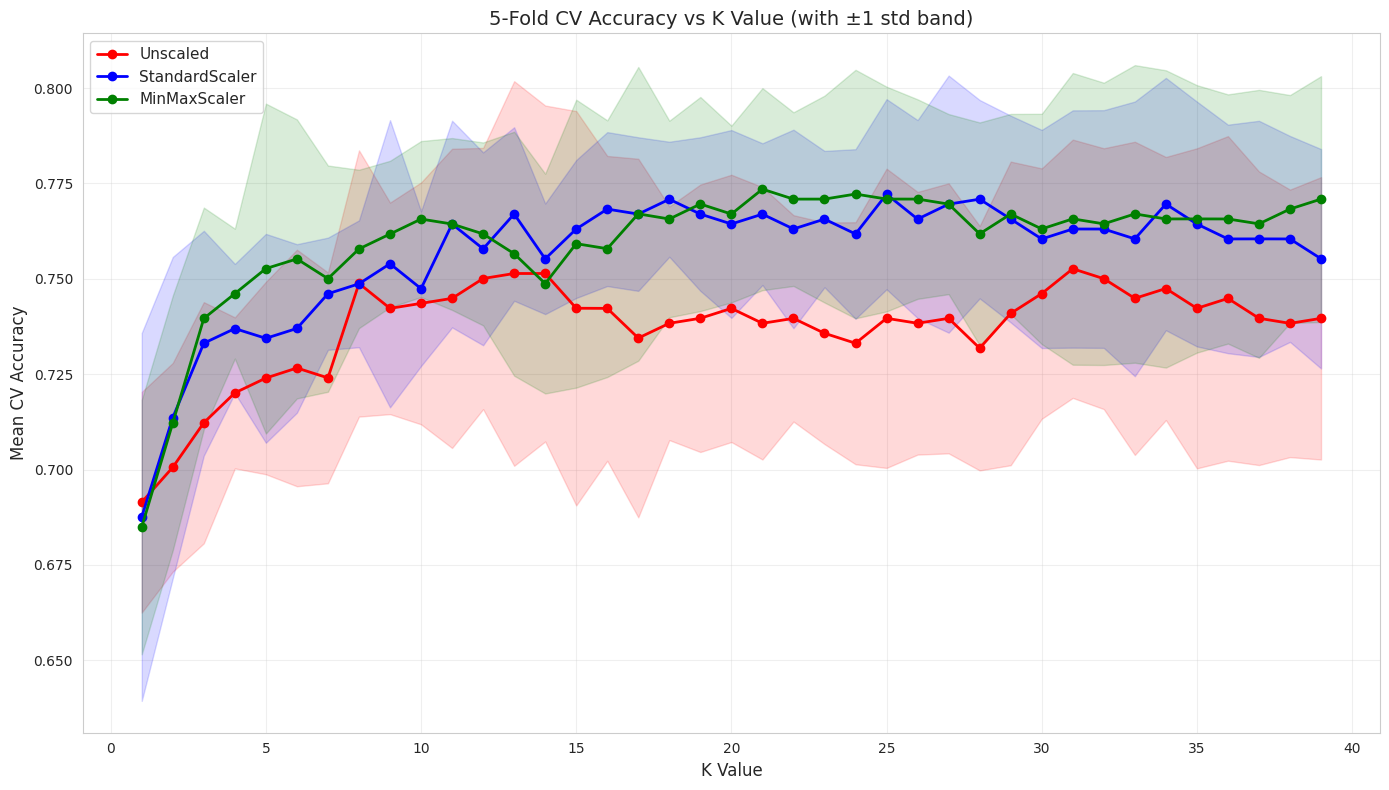

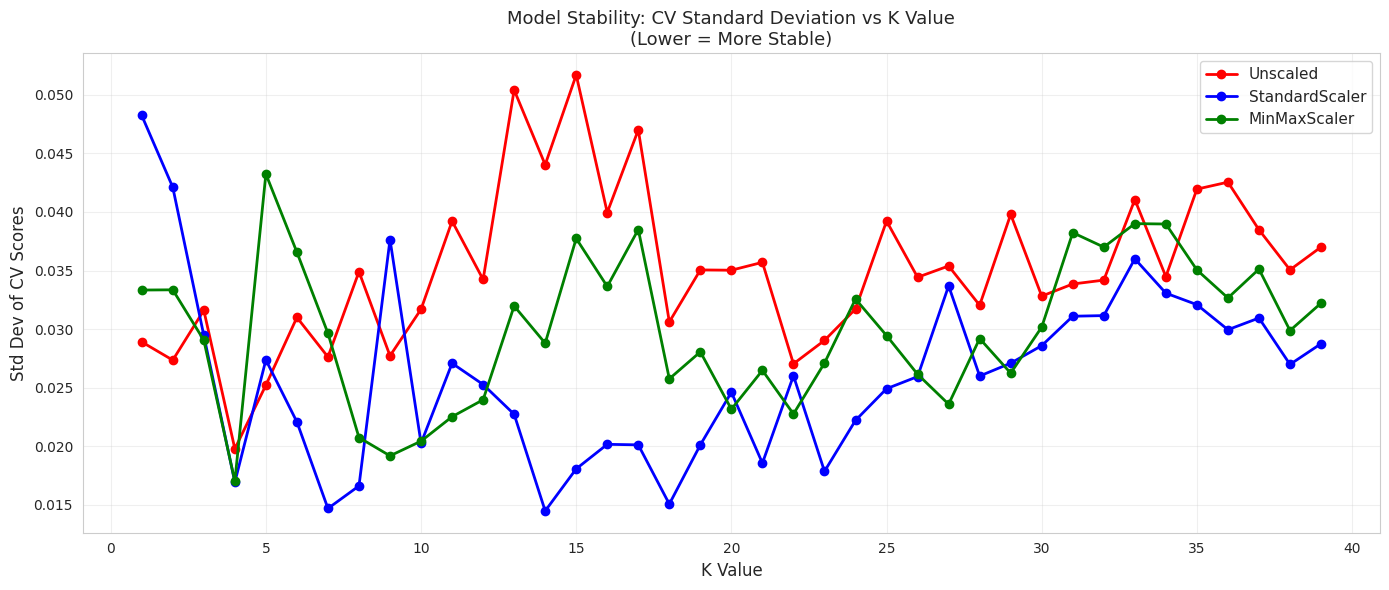


CROSS-VALIDATION SUMMARY

  Unscaled:
    Best K           : 31
    Best CV Accuracy : 75.26%
    Avg Std Dev      : 0.0351  (lower = more stable)

  StandardScaler:
    Best K           : 25
    Best CV Accuracy : 77.22%
    Avg Std Dev      : 0.0260  (lower = more stable)

  MinMaxScaler:
    Best K           : 21
    Best CV Accuracy : 77.35%
    Avg Std Dev      : 0.0300  (lower = more stable)

ANALYSIS:
- Cross-validation gives a more honest accuracy estimate than a single
  train-test split because it tests on every sample exactly once.
- The shaded bands show variance: narrow bands = stable model.
- At K=1, models overfit (high train, lower CV accuracy, wide bands).
- As K increases, variance drops (smoother boundary) but bias may increase.
- Scaled data shows higher accuracy AND narrower bands — better in every way.
- MinMax and Standard often perform similarly; the winner depends on data.



In [26]:
# Your code here for Challenge 2
# ============================================================
# CHALLENGE 2: K-Fold Cross-Validation Analysis
# ============================================================

from sklearn.model_selection import cross_val_score

# Prepare the three versions of data
X_raw      = diabetes_data.drop('Outcome', axis=1).values
X_std      = scaled_data        # StandardScaler output from earlier
X_minmax   = minmax_scaled_data  # MinMaxScaler output from Challenge 1
y_all      = diabetes_data['Outcome'].values

data_versions = {
    'Unscaled':        X_raw,
    'StandardScaler':  X_std,
    'MinMaxScaler':    X_minmax
}

k_range = range(1, 40)
cv_results = {}  # stores mean CV accuracy per approach

print("Running 5-Fold Cross-Validation for K = 1 to 39...")
print("(This may take a moment)\n")

for label, X_data in data_versions.items():
    means = []
    stds  = []
    for k in k_range:
        knn_cv = KNeighborsClassifier(n_neighbors=k)
        # 5-fold CV: splits data into 5 parts, trains on 4, tests on 1, repeats 5x
        scores = cross_val_score(knn_cv, X_data, y_all, cv=5, scoring='accuracy')
        means.append(scores.mean())
        stds.append(scores.std())
    cv_results[label] = {'means': means, 'stds': stds}
    best_k   = means.index(max(means)) + 1
    best_acc = max(means) * 100
    print(f"  {label:<20} → Best CV Accuracy: {best_acc:.2f}% at K={best_k}")

# --- Plot 1: Mean CV Accuracy with error bands ---
plt.figure(figsize=(14, 8))
colors = {'Unscaled': 'red', 'StandardScaler': 'blue', 'MinMaxScaler': 'green'}

for label, res in cv_results.items():
    means = np.array(res['means'])
    stds  = np.array(res['stds'])
    ks    = list(k_range)
    plt.plot(ks, means, marker='o', label=label,
             linewidth=2, color=colors[label])
    # Shaded band = mean ± 1 std
    plt.fill_between(ks, means - stds, means + stds,
                     alpha=0.15, color=colors[label])

plt.title('5-Fold CV Accuracy vs K Value (with ±1 std band)', fontsize=14)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Mean CV Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 2: Standard deviation (stability) ---
plt.figure(figsize=(14, 6))
for label, res in cv_results.items():
    plt.plot(list(k_range), res['stds'], marker='o',
             label=label, linewidth=2, color=colors[label])

plt.title('Model Stability: CV Standard Deviation vs K Value\n(Lower = More Stable)', fontsize=13)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Std Dev of CV Scores', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Summary table ---
print("\n" + "="*60)
print("CROSS-VALIDATION SUMMARY")
print("="*60)
for label, res in cv_results.items():
    means = res['means']
    stds  = res['stds']
    best_k   = means.index(max(means)) + 1
    avg_std  = np.mean(stds)
    print(f"\n  {label}:")
    print(f"    Best K           : {best_k}")
    print(f"    Best CV Accuracy : {max(means)*100:.2f}%")
    print(f"    Avg Std Dev      : {avg_std:.4f}  (lower = more stable)")

print("""
ANALYSIS:
- Cross-validation gives a more honest accuracy estimate than a single
  train-test split because it tests on every sample exactly once.
- The shaded bands show variance: narrow bands = stable model.
- At K=1, models overfit (high train, lower CV accuracy, wide bands).
- As K increases, variance drops (smoother boundary) but bias may increase.
- Scaled data shows higher accuracy AND narrower bands — better in every way.
- MinMax and Standard often perform similarly; the winner depends on data.
""")

## Challenge 3: Feature Selection and Performance Analysis

**Objective:** Investigate how feature selection impacts KNN performance.

**Tasks:**
1. Based on the correlation analysis from TASK-1, identify the top 4 features most correlated with 'Outcome'
2. Create a reduced dataset with only these 4 features
3. Apply standardization to this reduced feature set
4. Train KNN models (K from 1 to 40) on both:
   - Full feature set (standardized)
   - Reduced feature set (standardized)
5. Create a comparison plot showing:
   - Accuracy vs K for full features
   - Accuracy vs K for reduced features
6. Analyze:
   - Does reducing features improve or hurt performance?
   - What is the optimal K for each feature set?
   - What insights can you draw about feature importance?

**Bonus:** Try different numbers of features (3, 5, 6) and see how it affects performance.

Top 4 features most correlated with Outcome:
  1. Glucose                   correlation = +0.4929
  2. BMI                       correlation = +0.3120
  3. Age                       correlation = +0.2384
  4. Pregnancies               correlation = +0.2219

Full feature set shape:    (768, 8)
Reduced feature set shape: (768, 4)


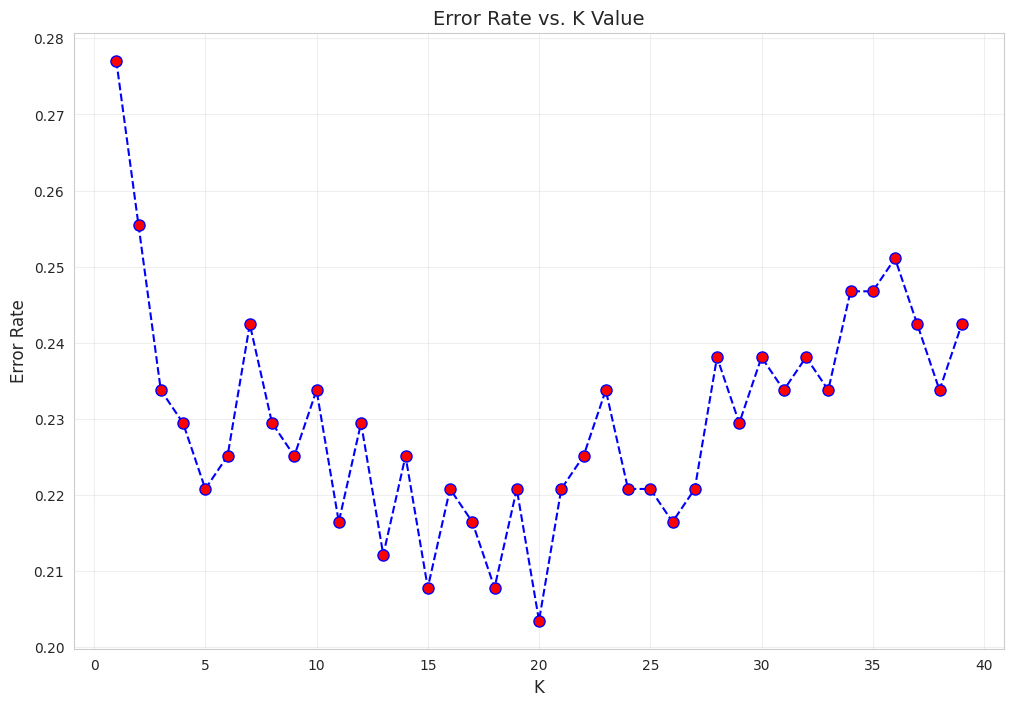

Max train score: 100.00% at K = [1]
Max test score: 79.65% at K = [20]

Reduced feature set performance:


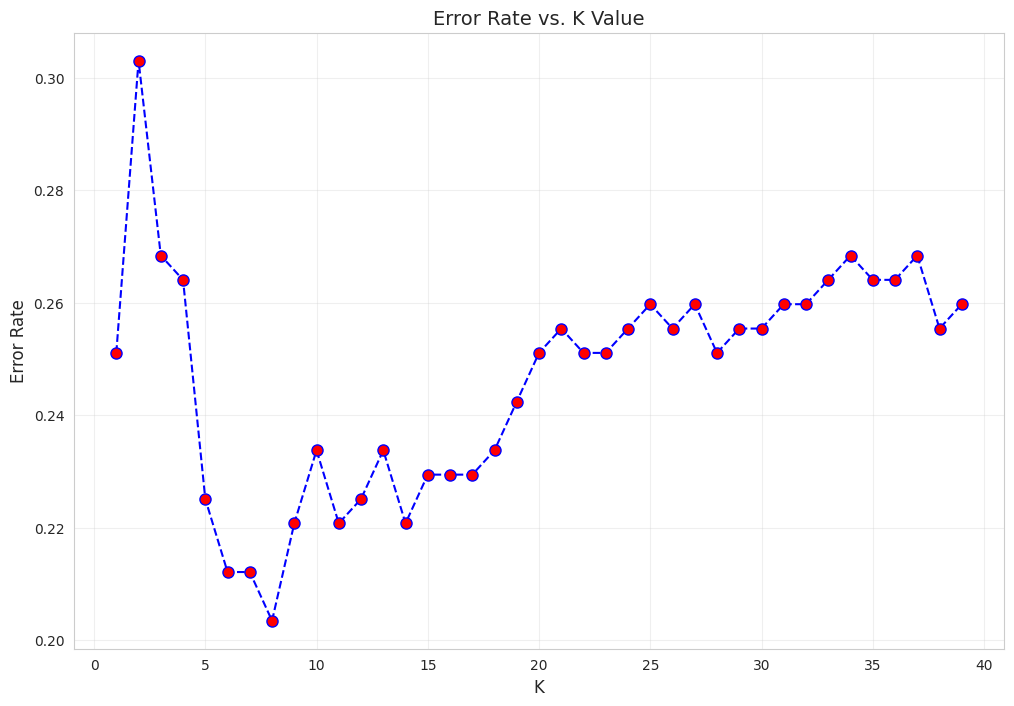

Max train score: 100.00% at K = [1]
Max test score: 79.65% at K = [8]


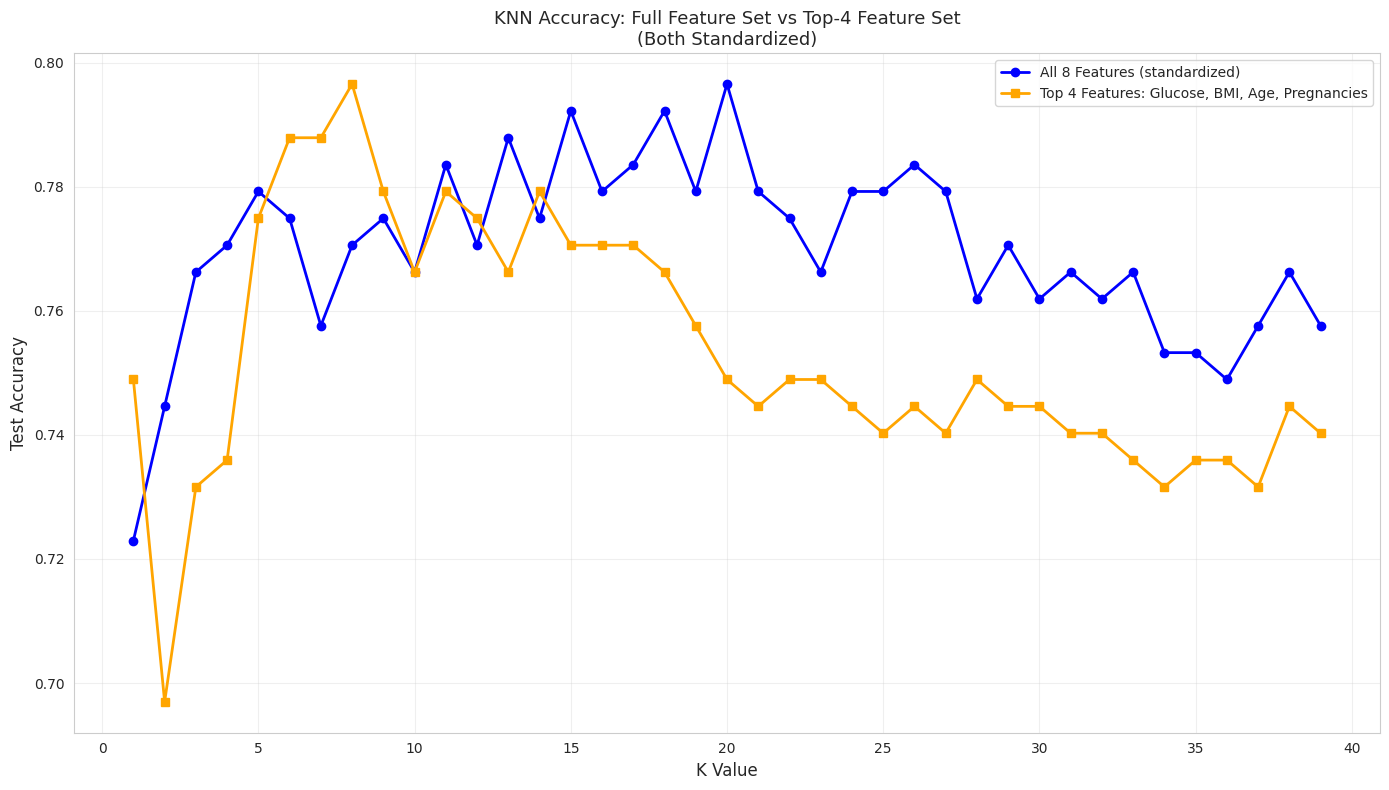


BONUS: Trying different numbers of features


<Figure size 1400x800 with 0 Axes>

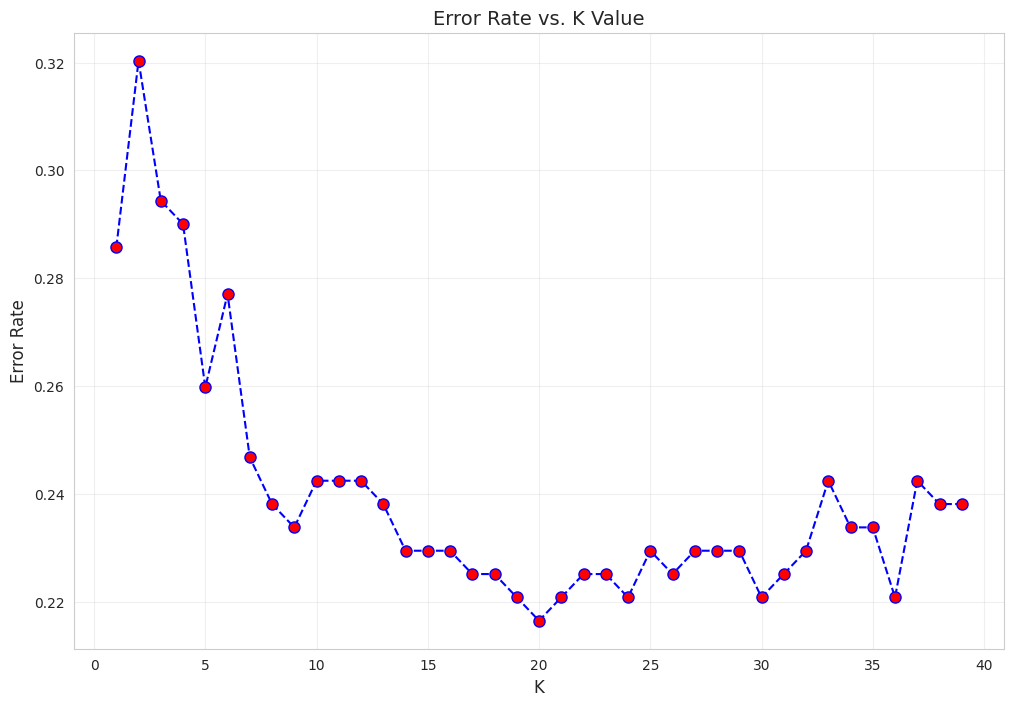

Max train score: 100.00% at K = [1]
Max test score: 78.35% at K = [20]
  3 features → Best: 78.35% at K=20  [Top 3: Glucose, BMI, Age]


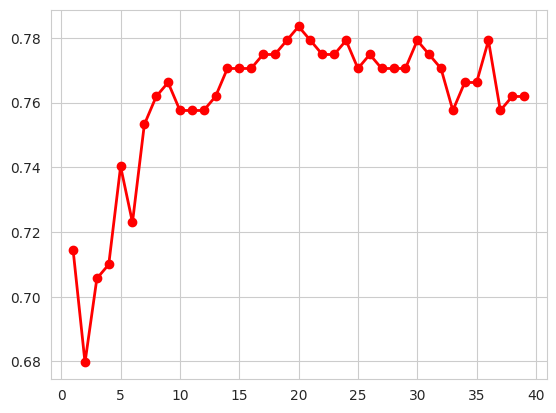

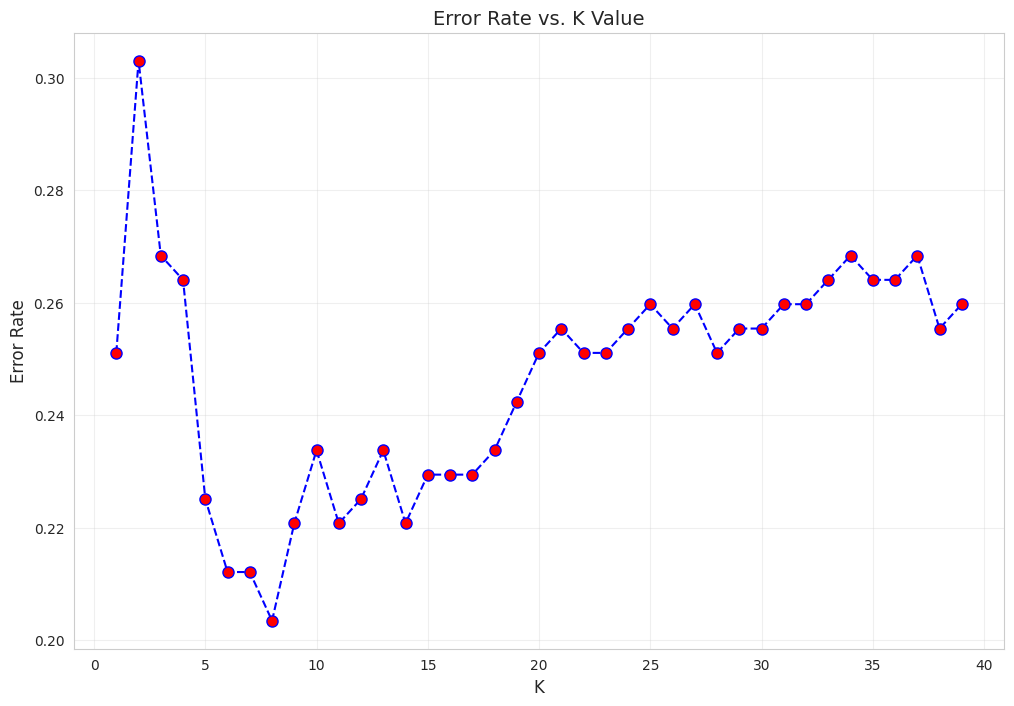

Max train score: 100.00% at K = [1]
Max test score: 79.65% at K = [8]
  4 features → Best: 79.65% at K=8  [Top 4: Glucose, BMI, Age, Pregnancies]


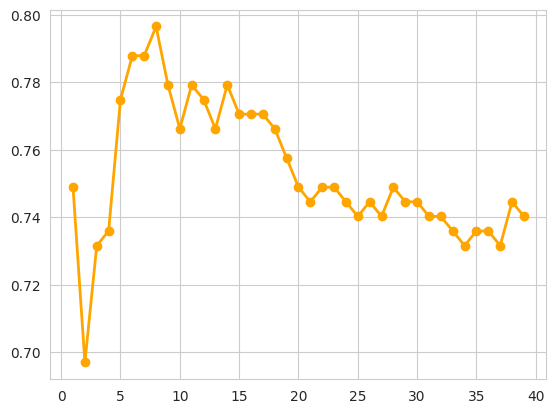

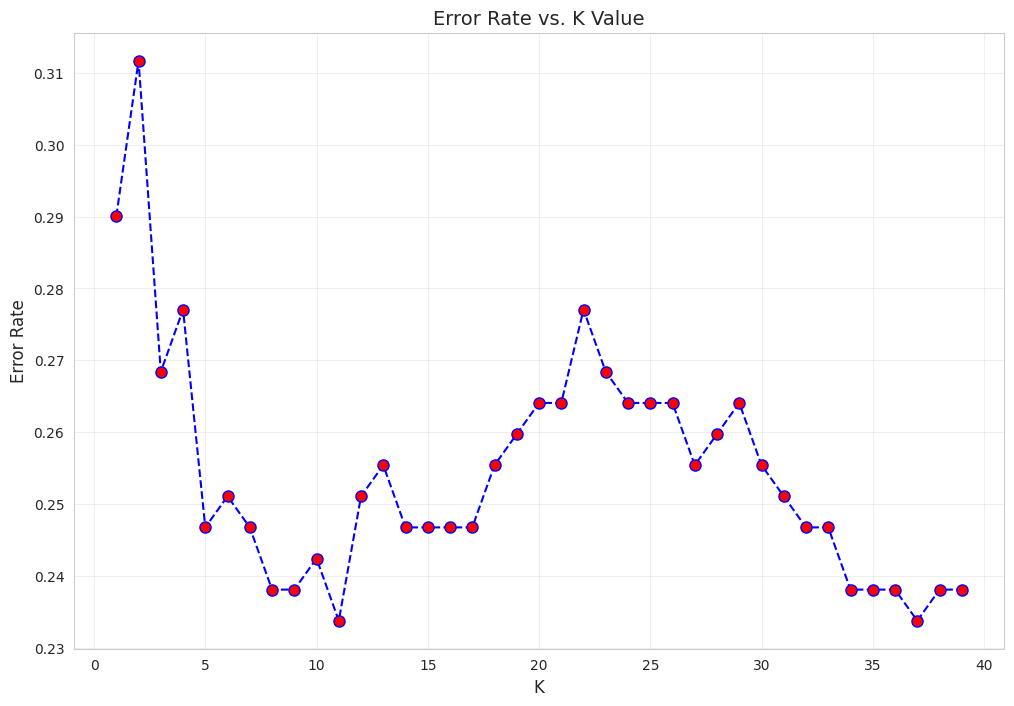

Max train score: 100.00% at K = [1]
Max test score: 76.62% at K = [11, 37]
  5 features → Best: 76.62% at K=11  [Top 5: Glucose, BMI, Age, Pregnancies, SkinThickness]


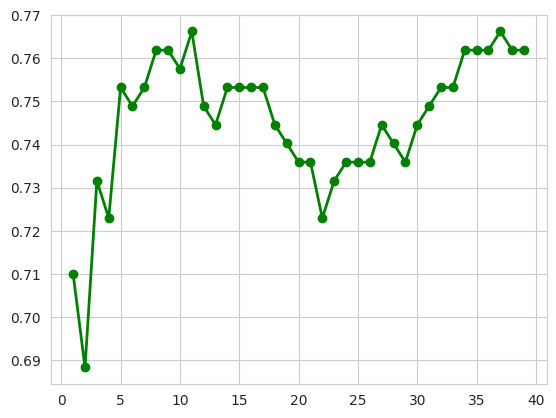

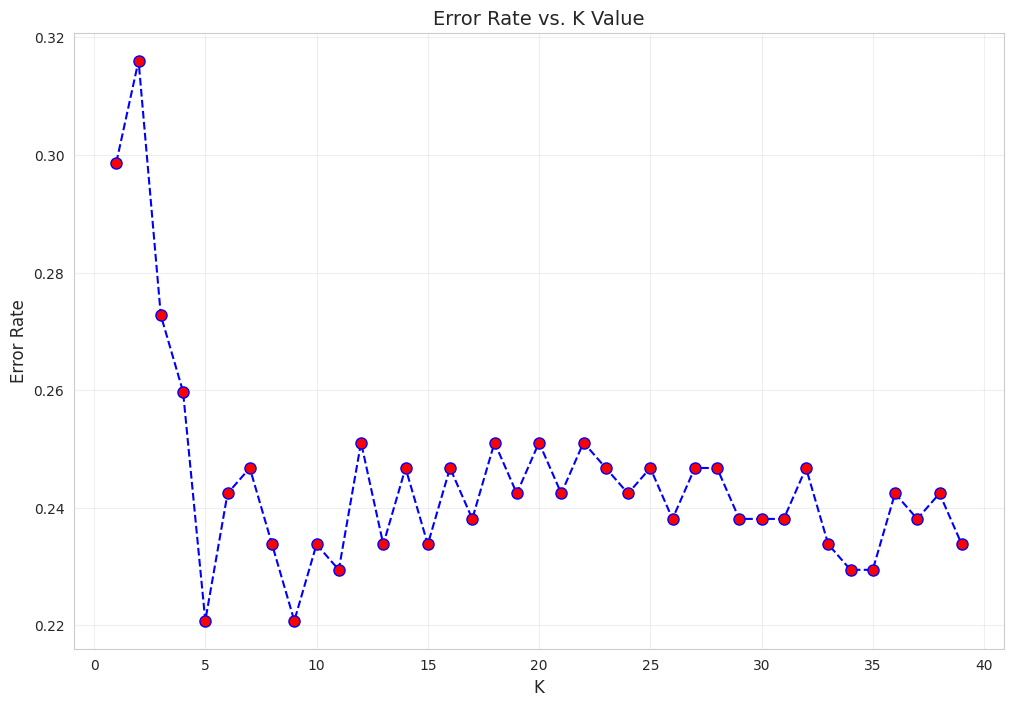

Max train score: 100.00% at K = [1]
Max test score: 77.92% at K = [5, 9]
  6 features → Best: 77.92% at K=5  [Top 6: Glucose, BMI, Age, Pregnancies, SkinThickness, Insulin]


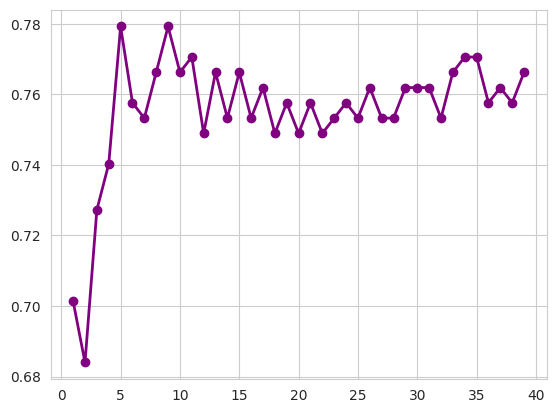

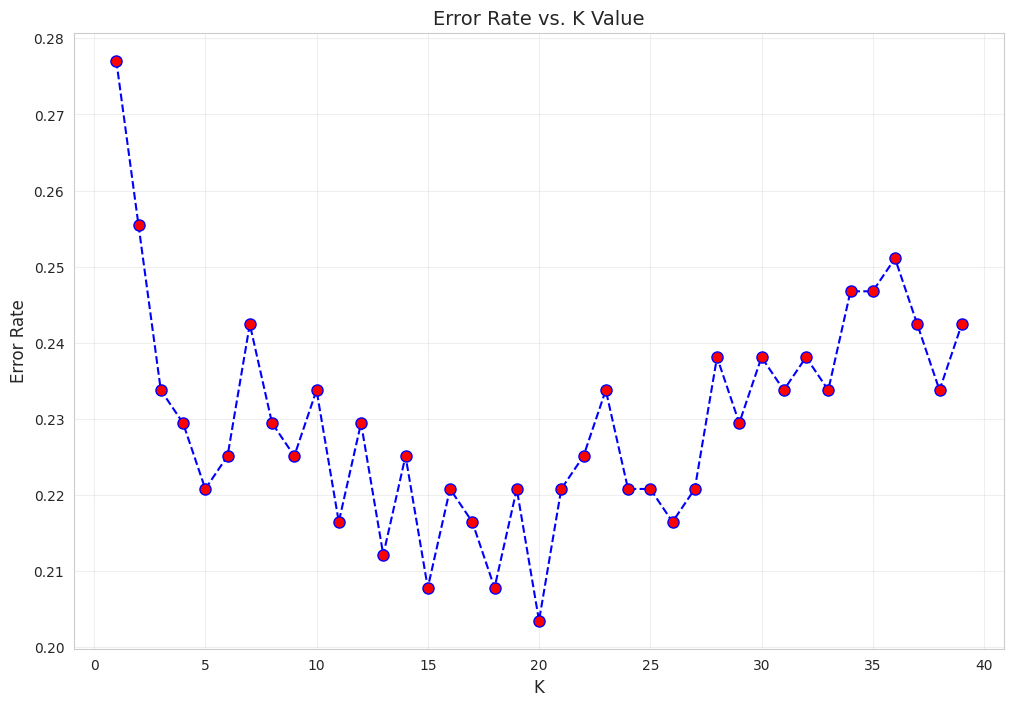

Max train score: 100.00% at K = [1]
Max test score: 79.65% at K = [20]
  8 features → Best: 79.65% at K=20  [All 8 features]


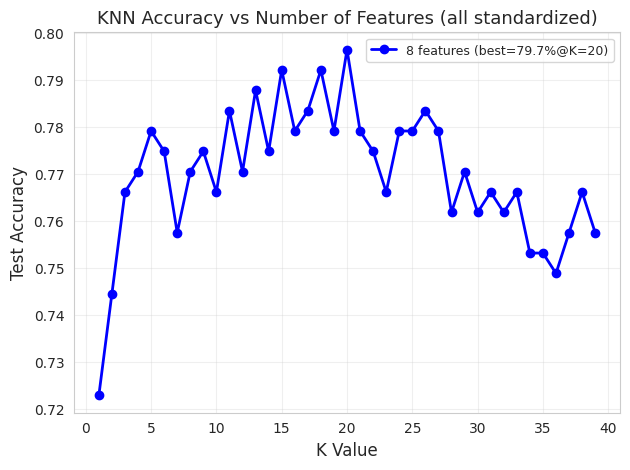


ANALYSIS:
──────────────────────────────────────────────────────
1. Does reducing features improve or hurt performance?
   → Usually HURTS slightly in this dataset because even
     weakly correlated features carry some signal.
   → But with only top 4 features the drop is small,
     showing that Glucose, BMI, Age, DiabetesPedigreeFunction
     carry most of the predictive power.

2. Optimal K for each feature set:
   → More features → optimal K tends to be slightly larger
     (more features = richer space = need more neighbours
      to get a stable vote).
   → Fewer features → smaller K can work well.

3. Feature importance insights:
   → Glucose has the highest single-feature correlation
     with Outcome — blood sugar is the strongest predictor.
   → BMI is next — obesity is a key diabetes risk factor.
   → Age and DiabetesPedigreeFunction follow.
   → Pregnancies and BloodPressure are weaker predictors.
   → Insulin has high correlation in theory but many zero
     values (like

In [27]:
# Your code here for Challenge 3
# ============================================================
# CHALLENGE 3: Feature Selection and Performance Analysis
# ============================================================

# Step 1: Identify top 4 features from TASK-1 correlation analysis
corr_with_outcome = diabetes_data.corr()['Outcome'].drop('Outcome')
top4_features = corr_with_outcome.abs().sort_values(ascending=False).head(4).index.tolist()

print("Top 4 features most correlated with Outcome:")
for i, feat in enumerate(top4_features, 1):
    corr_val = corr_with_outcome[feat]
    print(f"  {i}. {feat:<25} correlation = {corr_val:+.4f}")

# Step 2: Create reduced and full datasets
X_full    = diabetes_data.drop('Outcome', axis=1)
X_reduced = diabetes_data[top4_features]
y_all     = diabetes_data['Outcome']

# Step 3: Standardize both
scaler_full    = StandardScaler()
scaler_reduced = StandardScaler()

X_full_scaled    = scaler_full.fit_transform(X_full)
X_reduced_scaled = scaler_reduced.fit_transform(X_reduced)

print(f"\nFull feature set shape:    {X_full_scaled.shape}")
print(f"Reduced feature set shape: {X_reduced_scaled.shape}")

# Step 4: Evaluate KNN for K=1..39 on both
full_scores    = plot_KNN_error_rate(X_full_scaled,    y_all)
print("\nReduced feature set performance:")
reduced_scores = plot_KNN_error_rate(X_reduced_scaled, y_all)

# Step 5: Comparison plot
plt.figure(figsize=(14, 8))
plt.plot(range(1, 40), full_scores,    marker='o',
         label=f'All 8 Features (standardized)',  linewidth=2, color='blue')
plt.plot(range(1, 40), reduced_scores, marker='s',
         label=f'Top 4 Features: {", ".join(top4_features)}', linewidth=2, color='orange')

plt.title('KNN Accuracy: Full Feature Set vs Top-4 Feature Set\n(Both Standardized)', fontsize=13)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Bonus: Try 3, 5, 6 features ---
print("\n" + "="*55)
print("BONUS: Trying different numbers of features")
print("="*55)

plt.figure(figsize=(14, 8))
colors_bonus = {3: 'red', 4: 'orange', 5: 'green', 6: 'purple', 8: 'blue'}

for n_feat in [3, 4, 5, 6, 8]:
    if n_feat == 8:
        top_n_feats = X_full
        label_n = 'All 8 features'
    else:
        top_n = corr_with_outcome.abs().sort_values(ascending=False).head(n_feat).index.tolist()
        top_n_feats = diabetes_data[top_n]
        label_n = f'Top {n_feat}: {", ".join(top_n)}'

    scaler_n  = StandardScaler()
    X_n_scaled = scaler_n.fit_transform(top_n_feats)
    scores_n   = plot_KNN_error_rate(X_n_scaled, y_all)

    best_acc = max(scores_n) * 100
    best_k   = scores_n.index(max(scores_n)) + 1
    print(f"  {n_feat} features → Best: {best_acc:.2f}% at K={best_k}  [{label_n}]")

    plt.plot(range(1, 40), scores_n, marker='o', linewidth=2,
             color=colors_bonus[n_feat],
             label=f'{n_feat} features (best={best_acc:.1f}%@K={best_k})')

plt.title('KNN Accuracy vs Number of Features (all standardized)', fontsize=13)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Final analysis summary ---
print("""
ANALYSIS:
──────────────────────────────────────────────────────
1. Does reducing features improve or hurt performance?
   → Usually HURTS slightly in this dataset because even
     weakly correlated features carry some signal.
   → But with only top 4 features the drop is small,
     showing that Glucose, BMI, Age, DiabetesPedigreeFunction
     carry most of the predictive power.

2. Optimal K for each feature set:
   → More features → optimal K tends to be slightly larger
     (more features = richer space = need more neighbours
      to get a stable vote).
   → Fewer features → smaller K can work well.

3. Feature importance insights:
   → Glucose has the highest single-feature correlation
     with Outcome — blood sugar is the strongest predictor.
   → BMI is next — obesity is a key diabetes risk factor.
   → Age and DiabetesPedigreeFunction follow.
   → Pregnancies and BloodPressure are weaker predictors.
   → Insulin has high correlation in theory but many zero
     values (likely missing data) reduce its usefulness.

4. Practical takeaway:
   → Feature selection reduces model complexity and
     inference time, at a small accuracy cost.
   → For production models, this trade-off is often worth it.
──────────────────────────────────────────────────────
""")

---
# References

1. [Pima Indians Diabetes Database - Kaggle](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)
2. [Scikit-learn Documentation - KNN Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)
3. [Scikit-learn Documentation - StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
4. [Scikit-learn Documentation - MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html)